# 1. Dependencies and Dataset Preparation
First, we import the necessary PyTorch modules and download the MNIST dataset.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. Loading and Normalizing the Dataset
# We use a batch size of 32 for training and 500 for testing.
# Normalization uses the mean (0.1302) and std (0.3069) of the MNIST training set[cite: 519, 524].
train_dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1302,), (0.3069,))])),
    batch_size=32, shuffle=True)

test_dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1302,), (0.3069,))])),
    batch_size=500, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 608kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.51MB/s]


# 2. Model Architecture
The architecture consists of two convolutional layers followed by two fully connected layers.

In [2]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        # Convolutional Layer 1: 1 input channel (grayscale), 16 output channels, 3x3 kernel [cite: 464, 471]
        self.cn1 = nn.Conv2d(1, 16, 3, 1)
        # Convolutional Layer 2: 16 input channels, 32 output channels, 3x3 kernel [cite: 464, 473]
        self.cn2 = nn.Conv2d(16, 32, 3, 1)
        # Dropout layers to prevent overfitting [cite: 465]
        self.dp1 = nn.Dropout2d(0.10)
        self.dp2 = nn.Dropout2d(0.25)
        # Fully Connected Layer 1: 4608 input features (from flattened 12x12x32) to 64 [cite: 466]
        self.fc1 = nn.Linear(4608, 64)
        # Fully Connected Layer 2: 64 to 10 (representing digits 0-9) [cite: 466]
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # Apply Conv1 followed by ReLU activation [cite: 467]
        x = self.cn1(x)
        x = F.relu(x)
        # Apply Conv2 followed by ReLU and Max Pooling [cite: 477, 478]
        x = self.cn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        # Apply Dropout and Flatten for the Linear layers [cite: 478, 479]
        x = self.dp1(x)
        x = torch.flatten(x, 1)
        # Fully connected pass with ReLU and second Dropout [cite: 480, 483]
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dp2(x)
        x = self.fc2(x)
        # Output log-probabilities using LogSoftmax [cite: 483]
        op = F.log_softmax(x, dim=1)
        return op

# 3. Training and Testing Routines
These functions manage the optimization loop and model evaluation.

In [4]:
def train(model, device, train_dataloader, optimizer, epoch):
    model.train() # Set model to training mode
    for b_i, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad() # Clear existing gradients [cite: 500]
        pred_prob = model(X) # Forward pass
        loss = F.nll_loss(pred_prob, y) # Compute Negative Log Likelihood loss [cite: 501]
        loss.backward() # Backpropagation [cite: 502]
        optimizer.step() # Update weights [cite: 502]

        if b_i % 100 == 0: # Print status every 100 batches
            print(f'Train Epoch: {epoch} [{b_i * len(X)}/{len(train_dataloader.dataset)} '
                  f'({100. * b_i / len(train_dataloader):.0f}%)]\tLoss: {loss.item():.6f}')

def test(model, device, test_dataloader):
    model.eval() # Set model to evaluation mode [cite: 506]
    test_loss = 0
    correct = 0
    with torch.no_grad(): # Disable gradient calculation for efficiency [cite: 507]
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            pred_prob = model(X)
            test_loss += F.nll_loss(pred_prob, y, reduction='sum').item() # Sum batch loss [cite: 510]
            pred = pred_prob.argmax(dim=1, keepdim=True) # Get the index of the max log-probability [cite: 512]
            correct += pred.eq(y.view_as(pred)).sum().item() # Count matches

    test_loss /= len(test_dataloader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, '
          f'Accuracy: {correct}/{len(test_dataloader.dataset)} '
          f'({100. * correct / len(test_dataloader.dataset):.0f}%)\n')

# 4. Running the Training
This block initializes the model and runs the training for 2 epochs.

In [5]:
# Setup device and model [cite: 535, 536]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvNet().to(device)

# We use Adadelta optimizer with a learning rate of 0.5 [cite: 536, 538]
optimizer = optim.Adadelta(model.parameters(), lr=0.5)

# Train for 2 epochs
for epoch in range(1, 3):
    train(model, device, train_dataloader, optimizer, epoch)
    test(model, device, test_dataloader)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Train Epoch: 1 [0/60000 (0%)]	Loss: 2.295586
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.458803
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.174520
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.117915
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.188936
Train Epoch: 1 [16000/60000 (27%)]	Loss: 0.206551
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.190436
Train Epoch: 1 [22400/60000 (37%)]	Loss: 0.202372
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.238419
Train Epoch: 1 [28800/60000 (48%)]	Loss: 0.021849
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.141130
Train Epoch: 1 [35200/60000 (59%)]	Loss: 0.019475
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.211475
Train Epoch: 1 [41600/60000 (69%)]	Loss: 0.008417
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.084753
Train Epoch: 1 [48000/60000 (80%)]	Loss: 0.039854
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.157791
Train Epoch: 1 [54400/60000 (91%)]	Loss: 0.011337
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.001396

Test set: Average loss: 0.0488, Accuracy: 9842/10000 (98%)

# 5. Inference on a SampleFinally, visualize a sample from the test set and see the model's prediction.

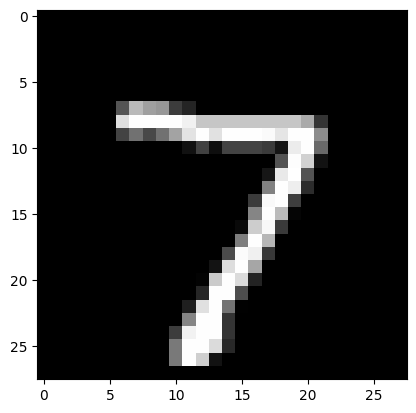

Model prediction: 7
Ground truth: 7


In [6]:
# Extract a single sample for testing
test_samples = enumerate(test_dataloader)
_, (sample_data, sample_targets) = next(test_samples)

# Visualize the first image in the batch [cite: 557, 558]
plt.imshow(sample_data[0][0], cmap='gray')
plt.show()

# Run prediction [cite: 568]
model.eval()
with torch.no_grad():
    output = model(sample_data.to(device))
    prediction = output[0].argmax(dim=0).item()
    print(f"Model prediction: {prediction}")
    print(f"Ground truth: {sample_targets[0].item()}")

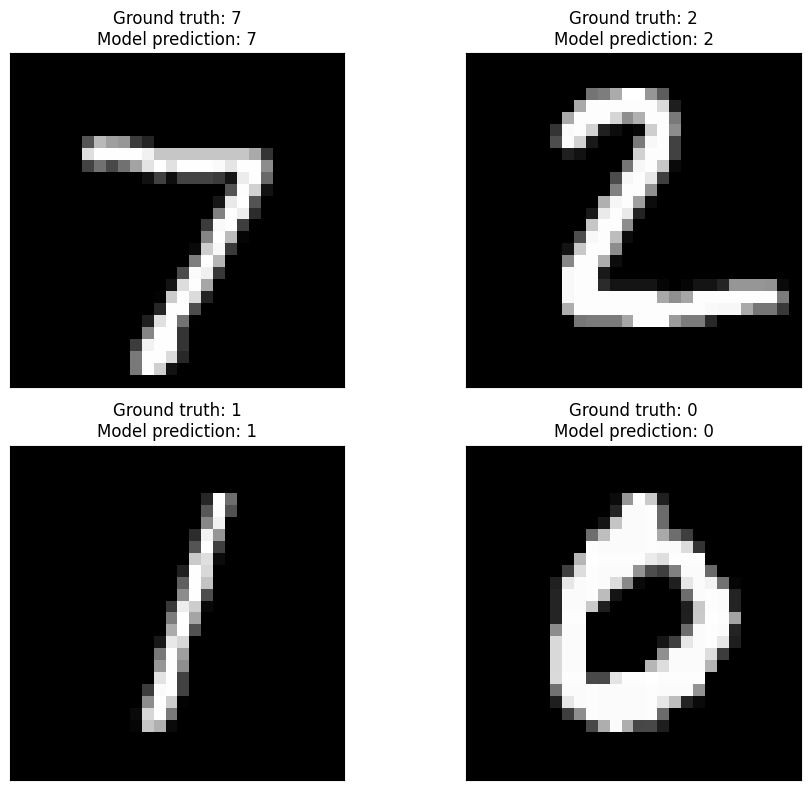

In [11]:
# 1. Get a batch of samples from the test dataloader
test_samples = enumerate(test_dataloader)
_, (sample_data, sample_targets) = next(test_samples)

# 2. Set model to evaluation mode and run inference
model.eval()
with torch.no_grad():
    # Pass the entire batch of sample_data to the device (CPU/GPU)
    output = model(sample_data.to(device))
    # Get the index of the highest probability for each sample in the batch
    predictions = output.argmax(dim=1)

# 3. Plot 6 samples in a grid
plt.figure(figsize=(10, 8)) # Set the figure size
for i in range(4):
    plt.subplot(2, 2, i+1) # Create a 2x3 grid

    # Display the image [cite: 556, 557]
    # Note: Using sample_data[i][0] because images are (Batch, Channel, H, W)
    plt.imshow(sample_data[i][0], cmap='gray', interpolation='none')

    # Get the actual and predicted labels
    actual = sample_targets[i].item()
    pred = predictions[i].item()

    # Set the title to show Actual vs Predicted
    plt.title(f"Ground truth: {actual}\nModel prediction: {pred}")
    plt.xticks([]) # Hide X-axis markers
    plt.yticks([]) # Hide Y-axis markers

plt.tight_layout()
plt.show()